# Stability Augmentation System (SAS)

In [ ]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os
from pathlib import Path

try:
  import jsbsim
  print('JSBSim is installed')
  # Relative path to the directory where the flight model is stored
  # Note - Aircraft directory needs to be writeable in order to modify the cg
  PATH_TO_JSBSIM_FILES= str(Path.cwd().parent.parent.parent / "jsbsim")
  print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      %pip install jsbsim
      # Use the standard aircraft supplied by the JSBSim Python package
      PATH_TO_JSBSIM_FILES=None

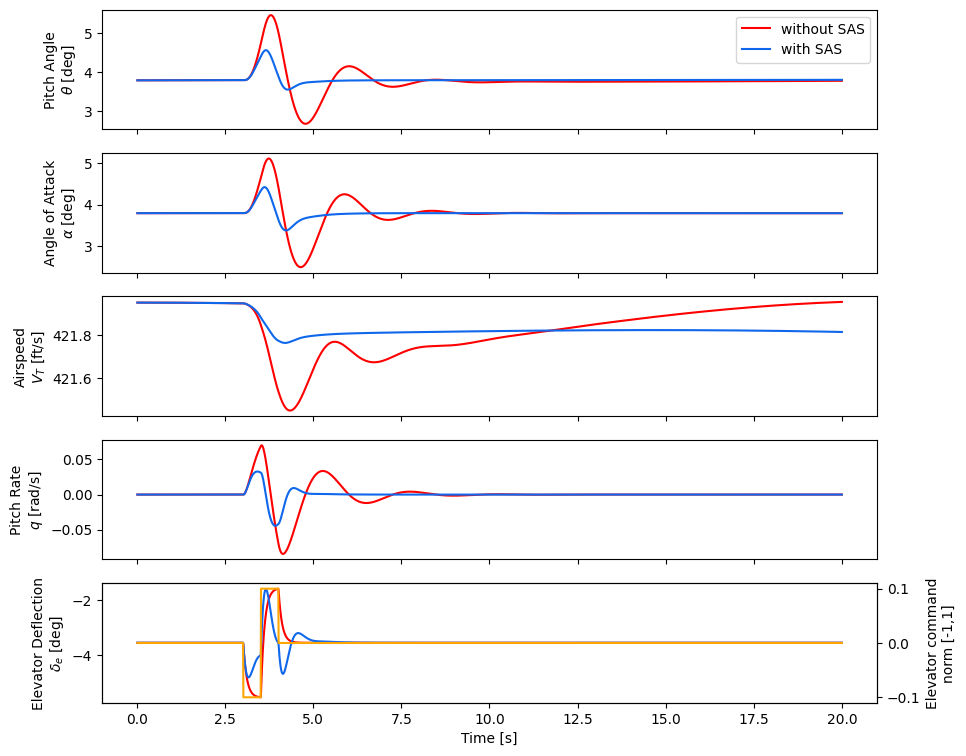

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration Section ---
# Global variables that must be modified to match your particular need
# The aircraft name
# Note - It should match the exact spelling of the model file
AIRCRAFT_NAME="A4"

# --- JSBSim Initialization ---
# These lines initialize the flight dynamics model.

# Avoid flooding the console with log messages
jsbsim.FGJSBBase().debug_lvl = 0

# Create a flight dynamics model (FDM) instance.
fdm = jsbsim.FGFDMExec(PATH_TO_JSBSIM_FILES)

# Load the aircraft model
fdm.load_model(AIRCRAFT_NAME)

def run_simulation(sas_active):

    fdm.reset_to_initial_conditions(0)
    # Set engines running
    fdm['propulsion/engine[0]/set-running'] = 1 # always motor running?
    # Get the simulation time step (delta time).
    dt = fdm.get_delta_t()
    
    # --- Data Storage ---
    # This section initializes lists to record simulation data.
    data = { 'times':[],
             'thetas': [],
             'alphas': [],
             'airspeeds': [],
             'pitchRates': [],
             'elevator_pos': [],
             'elevator_commands': []
             }

    # --- Simulation Initialization ---
    # This line initializes the flight dynamics model.

    # Initial conditions
    fdm['ic/h-sl-ft']   = 8000  #altitude above sea level (ft)
    fdm['ic/vt-kts']    = 250    #calibrated airspeed (kts)
    fdm['ic/gamma-deg'] = 0   #flight path angle (deg)
    fdm['ic/beta-deg']  = 0    #sideslip angle (deg)

    # Initialize the aircraft with initial conditions
    fdm.run_ic()
    
    # Attempt to trim the aircraft.
    try:
        # 1 means straight flight by using all changeable control variables.   
        fdm['simulation/do_simple_trim'] = 1   
    except jsbsim.TrimFailureError:
        print("Trim failed, continuing rudder kick in an untrimmed state.")
        pass  # Ignore trim failure

    # --- Simulation Loop ---
    # This is the main simulation loop that runs the simulation for a specified duration.

    # Time to run for in seconds.
    run_period = 20

    # Start the doublet 2 seconds into the simulation to ensure we are in a steady trim.
    doublet_start_time = 3.0  
    doublet_width = 0.5       # Duration of each pulse in seconds.
    doublet_amplitude = 0.1   # Magnitude of the elevator deflection (normalized -1 to 1).

    for i in range(int(run_period/dt)):
        # Advance the simulation by one time step.
        fdm.run()
        
        # Record the simulation data.
        data['times'].append(fdm.get_sim_time())
        data['thetas'].append(fdm['attitude/theta-deg'])
        data['alphas'].append(fdm['aero/alpha-deg'])
        data['airspeeds'].append(fdm['velocities/vt-fps'])
        data['pitchRates'].append(fdm['velocities/q-rad_sec']) 
        data['elevator_commands'].append(fdm['fcs/elevator-cmd-norm'])
        data['elevator_pos'].append(fdm['fcs/elevator-pos-deg'])
        
        # pitch sas system
        fdm['fcs/sas-active-switch'] = sas_active
        # Get the current simulation time
        current_time = fdm.get_sim_time()

        # Doublet Logic: three distinct phases
        # Phase A: The first "up" pulse
        if doublet_start_time <= current_time < (doublet_start_time + doublet_width):
            elevator_cmd = -doublet_amplitude  # "pull" for pitch up.

        # Phase B: The second "down" pulse
        elif (doublet_start_time + doublet_width) <= current_time < (doublet_start_time + 2 * doublet_width):
            elevator_cmd = doublet_amplitude   # "push" for pitch down.

        # Phase C: Return to neutral
        else:
            elevator_cmd = 0.0

        # Apply the command to the elevator property
        fdm['fcs/elevator-cmd-norm'] = elevator_cmd
    
    return data

data_no_sas = run_simulation(sas_active=0)
data_with_sas= run_simulation(sas_active=1)



   
# --- Plot Results ---
# This section plots the simulation results.
fig, axes = plt.subplots(5,1,figsize=(10,9),sharex=True)
ax_theta, ax_alpha, ax_vt, ax_q, ax_elev = axes

color2 = "#FF0000"
color1 = "#0F67EB"
lw1 = 1.5
lw2 = 1.5
# setup individual lines and labels
ax_theta.plot(data_no_sas['times'],data_no_sas['thetas'], color= color2, linewidth=lw1, label="without SAS")
ax_alpha.plot(data_no_sas['times'],data_no_sas['alphas'], color= color2,linewidth=lw1)
ax_vt.plot(data_no_sas['times'],data_no_sas['airspeeds'], color= color2,linewidth=lw1)
ax_q.plot(data_no_sas['times'],data_no_sas['pitchRates'], color= color2,linewidth=lw1)
ax_elev.plot(data_no_sas['times'],data_no_sas['elevator_pos'], color= color2,linewidth=lw1)

# setup individual lines and labels
ax_theta.plot(data_with_sas['times'],data_with_sas['thetas'], color= color1, linewidth=lw1, label="with SAS")
ax_alpha.plot(data_with_sas['times'],data_with_sas['alphas'], color= color1,linewidth=lw1)
ax_vt.plot(data_with_sas['times'],data_with_sas['airspeeds'], color= color1,linewidth=lw1)
ax_q.plot(data_with_sas['times'],data_with_sas['pitchRates'], color= color1,linewidth=lw1)
ax_elev.plot(data_with_sas['times'],data_with_sas['elevator_pos'], color= color1,linewidth=lw1)

ax_elev.set_xlabel("Time [s]")
ax_theta.legend(loc='upper right')  

# Create a secondary y-axis for the control command input
ax2 = ax_elev.twinx()
ax2.plot(data_no_sas['times'], data_no_sas['elevator_commands'], color='orange', label= "elevator cmd")
ax2.set_ylabel("Elevator command" + "\n" + "norm [-1,1]")

# Create labels for the results
labels = ["Pitch Angle" + "\n" + r"$\theta$ [deg]", "Angle of Attack" + "\n" + r"$\alpha$ [deg]", 
          "Airspeed" + "\n" + r"$V_T$ [ft/s]", "Pitch Rate" + "\n" + r"$q$ [rad/s]", 
          "Elevator Deflection" + "\n" + r"$\delta_e$ [deg]"]
for ax,label in zip(axes, labels):
    ax.set_ylabel(label)

# Display the plot.
plt.show()

# Stability analysis
## Short period 

In [ ]:
import control
# LOngitudinal dynamics
fdm.reset_to_initial_conditions(0)
lin = jsbsim.FGLinearization(fdm)

A = lin.system_matrix
B = lin.input_matrix
C = np.array([[0, 0, 1, 0],[0, 0, 0, 1]])

A_long = A[0:4, 0:4]
#print(A_long)
B_long = B[0:4,[2]] #4x1 input matrix delta_elevator input
#eigenvalues = np.linalg.eigvals(A_long)

D = np.zeros((2,1))

# BUild extended system: Aircraft dynamics + actuator
# Define Actuator Characteristics (time constant tau = 0.1s -> bandwidth = 10 rad/s)
tau = 0.1
wa = 1.0 / tau

top_block = np.block([A_long, -B_long])
bottom_row = np.array([[0.0, 0.0, 0.0, 0.0, -wa]])
A_aug = np.vstack([top_block, bottom_row])
eigenvalues1 = np.linalg.eigvals(A_aug)
#print(eigenvalues1)
# Build the New Input Matrix (B_augmented)
# The control command goes now to the actuator, not directly to the airframe
B_aug = np.array([[0.0], [0.0], [0.0], [0.0], [wa]])
C_aug = np.block([C,np.zeros((2,1))])

#Create the State-Space System
sys = control.ss(A_aug, B_aug, C_aug, D)

wn, damping_ratios, poles = control.damp(sys)

#print(f"\nNatural Frequency: {wn[0]:.2f} rad/s")
#print(f"Damping Ratio: {damping_ratios[0]:.2f}")
k_q=0.869
K = np.array([[0, k_q]])

# Closed-loop matrix 
acl = A_aug - B_aug @ K @ C_aug
eigenvalues = np.linalg.eigvals(acl)
#print(eigenvalues)
sys2 = control.ss(acl, B_aug,C_aug[1,:],0)
wn2, damping_ratios2, poles2 = control.damp(sys2)

    Eigenvalue (pole)       Damping     Frequency
   -0.8538    +2.424j        0.3322          2.57
   -0.8538    -2.424j        0.3322          2.57
  -0.01191  +0.09041j        0.1306       0.09119
  -0.01191  -0.09041j        0.1306       0.09119
                  -10             1            10
    Eigenvalue (pole)       Damping     Frequency
               -7.346             1         7.346
     -2.18    +2.566j        0.6476         3.367
     -2.18    -2.566j        0.6476         3.367
  -0.01219  +0.08028j        0.1501        0.0812
  -0.01219  -0.08028j        0.1501        0.0812
